In [2]:
pip install "numpy<2.0.0"

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 837.5 kB/s eta 0:00:19
   - -------------------------------------- 0.8/15.8 MB 860.9 kB/s eta 0:00:18
   - -------------------------------------- 0.8/15.8 MB 860.9 kB/s eta 0:00:18
   -- ------------------------------------- 1.0/15.8 MB 853.0 kB/s eta 0:00:18
   --- ------------------------------------ 1.3/15.8 MB 907.1 kB/s eta 0:00:16
   ---- ----------------------------------- 1.8/15.8 MB 1.1 MB/s eta 0:00:13
   ----- ---------------------------------- 2.1/15.8 MB 1.2 MB/s eta 0:00:12
   ----- ---------------------------------- 2.4/15.8 MB 1.2 MB/s eta 0:00:12
   ------- -------------------------------- 2.9/15.8 MB 1.3 MB/s eta 0:00:11
   ------- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


# Img1


### Setup and Loading the Model

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from paddleocr import PaddleOCR

# Initialize the OCR engine
# use_angle_cls=True helps detect text that is rotated or sideways
ocr = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False)

print("Step 1: Model is ready!")

[2026/01/22 15:02:44] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\koush/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\koush/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_len

### show the image

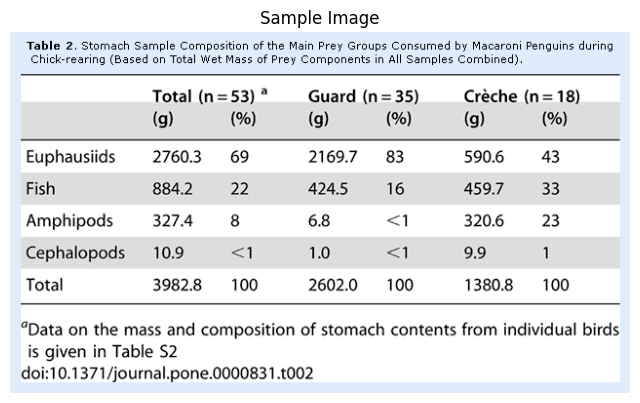

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the image
img = cv2.imread('sample.png')

# 2. Check if the image loaded correctly
if img is not None:
    # Convert BGR to RGB so colors look natural
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3. Display it
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off') # Hides the x and y ruler numbers
    plt.title("Sample Image")
    plt.show()
else:
    print("❌ Error: 'sample.png' not found. Make sure it's in the same folder!")

### Run OCR and Extract Data

In [3]:
image_path = 'sample.png'

# This line does the heavy lifting
result = ocr.ocr(image_path, cls=True)

# result[0] contains all the detected lines
# We extract just the boxes and the text into two easy-to-use lists
boxes = [line[0] for line in result[0]]
texts = [line[1][0] for line in result[0]]

print(f"✅ Step 2: Found {len(texts)} pieces of text.")

[2026/01/22 15:02:57] ppocr DEBUG: dt_boxes num : 49, elapse : 0.10711407661437988
[2026/01/22 15:02:57] ppocr DEBUG: cls num  : 49, elapse : 0.12398982048034668
[2026/01/22 15:03:02] ppocr DEBUG: rec_res num  : 49, elapse : 4.5826096534729
✅ Step 2: Found 48 pieces of text.


### Drawing the Boxes and Text

In [4]:
# Load the actual image file
img = cv2.imread(image_path)

# Create a copy so the original 'img' stays clean
img_plot = img.copy()

# 'zip' lets us look at the text and its box at the same time
for text, box in zip(texts, boxes):
    # 1. Convert coordinates to integers (OpenCV needs whole numbers)
    pts = np.array(box, dtype=int)
    
    # 2. Draw a green (0, 255, 0) line around the text
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    
    # 3. Get the top-left corner of the box to know where to write the text
    x, y = pts[0]
    
    # 4. Write the detected text in Blue (255, 0, 0) slightly above the box
    cv2.putText(img_plot, text, (x, y - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

print("✅ Step 3: Boxes and text drawn on the image copy.")

✅ Step 3: Boxes and text drawn on the image copy.


### Result

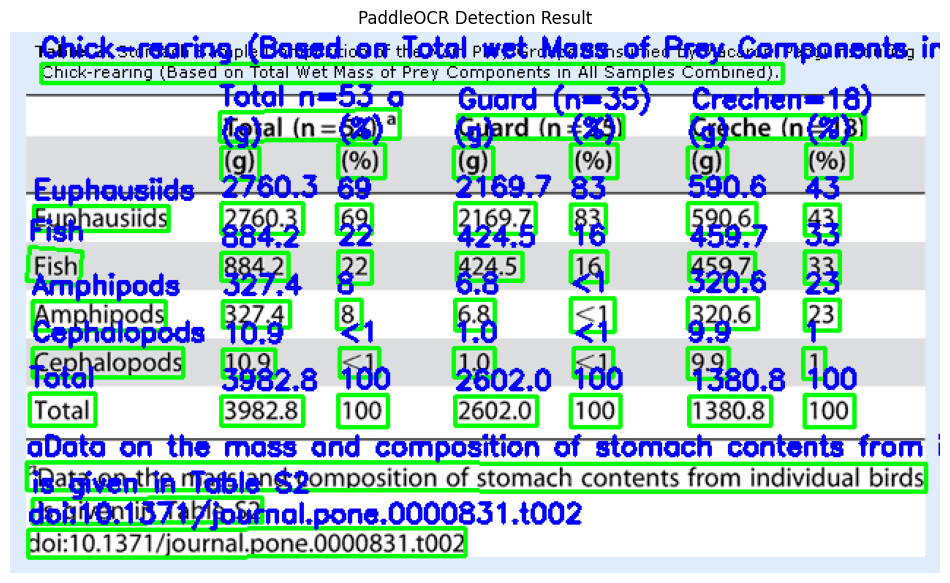

✅ Step 4: Visualization complete!


In [5]:
# Convert BGR (OpenCV format) to RGB (Standard display format)
final_output = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 15))
plt.imshow(final_output)
plt.axis("off") # Hide the x and y axis numbers
plt.title("PaddleOCR Detection Result")
plt.show()

print("✅ Step 4: Visualization complete!")

### Printing the Data (Table Format)


In [6]:
# Part 5: Print the text data to the console
print(f"{'INDEX':<10} | {'TEXT':<25} | {'CONFIDENCE'}")
print("-" * 50)

# We use enumerate to get a line number (i)
for i, line in enumerate(result[0]):
    text = line[1][0]
    score = line[1][1]
    
    # We use :.2f to show only 2 decimal places (e.g., 0.98)
    print(f"{i:<10} | {text:<25} | {score:.2f}")

print("\n✅ Step 5: Text data printed above.")

INDEX      | TEXT                      | CONFIDENCE
--------------------------------------------------
0          | Chick-rearing (Based on Total wet Mass of Prey Components in All Samples Combined). | 0.99
1          | Total n=53 a              | 0.95
2          | Guard (n=35)              | 0.91
3          | Crechen=18)               | 0.97
4          | (g)                       | 0.99
5          | (%)                       | 0.97
6          | (g)                       | 0.99
7          | (%)                       | 0.99
8          | (g)                       | 0.99
9          | (%)                       | 0.96
10         | Euphausiids               | 1.00
11         | 2760.3                    | 0.97
12         | 69                        | 1.00
13         | 2169.7                    | 0.96
14         | 83                        | 1.00
15         | 590.6                     | 1.00
16         | 43                        | 1.00
17         | Fish                      | 1.00
18         

# Img2

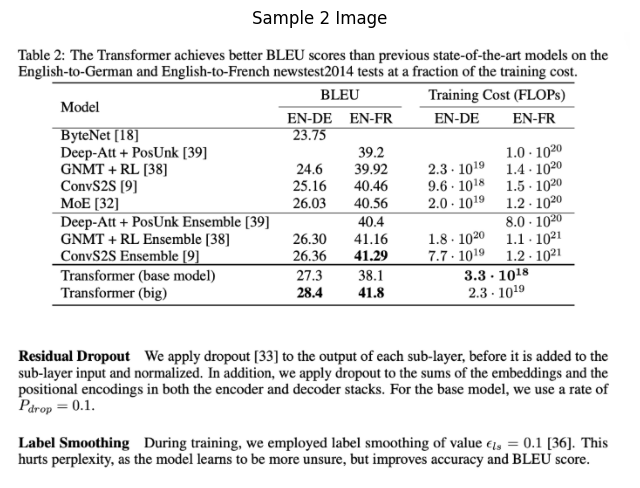

In [11]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the image
img2 = cv2.imread('sample2.png')

# 2. Check if the image loaded correctly
if img2 is not None:
    # Convert BGR to RGB so colors look natural
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # 3. Display it
    plt.figure(figsize=(8, 8))
    plt.imshow(img2_rgb)
    plt.axis('off') # Hides the x and y ruler numbers
    plt.title("Sample 2 Image")
    plt.show()
else:
    print("❌ Error: 'sample2.png' not found. Make sure it's in the same folder!")

In [7]:
# 1. Change the name to your new file
new_image_path = 'sample2.png' 

# 2. Run the OCR on the new image
# We use the 'ocr' object we created earlier
result2 = ocr.ocr(new_image_path, cls=True)

print(f"✅ Processed {new_image_path} successfully!")

[2026/01/22 15:07:44] ppocr DEBUG: dt_boxes num : 56, elapse : 0.4073367118835449
[2026/01/22 15:07:44] ppocr DEBUG: cls num  : 56, elapse : 0.14590120315551758
[2026/01/22 15:07:51] ppocr DEBUG: rec_res num  : 56, elapse : 7.229406118392944
✅ Processed sample2.png successfully!


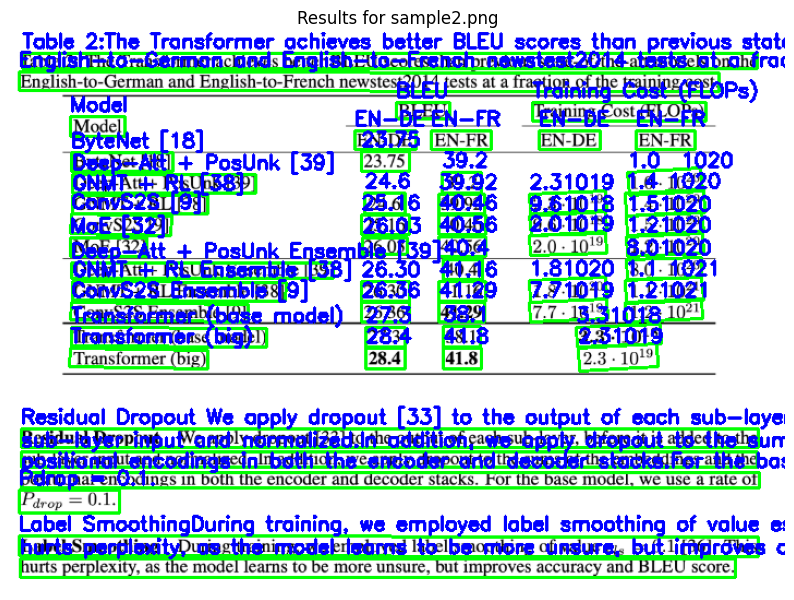

In [8]:
# Load the new image
img2 = cv2.imread(new_image_path)
img_plot2 = img2.copy()

# Extract boxes and texts from result2
for line in result2[0]:
    box = line[0]
    text = line[1][0]
    
    # Draw logic (same as before)
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot2, [pts], True, (0, 255, 0), 2)
    
    x, y = pts[0]
    cv2.putText(img_plot2, text, (x, y - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Show it
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_plot2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Results for {new_image_path}")
plt.show()

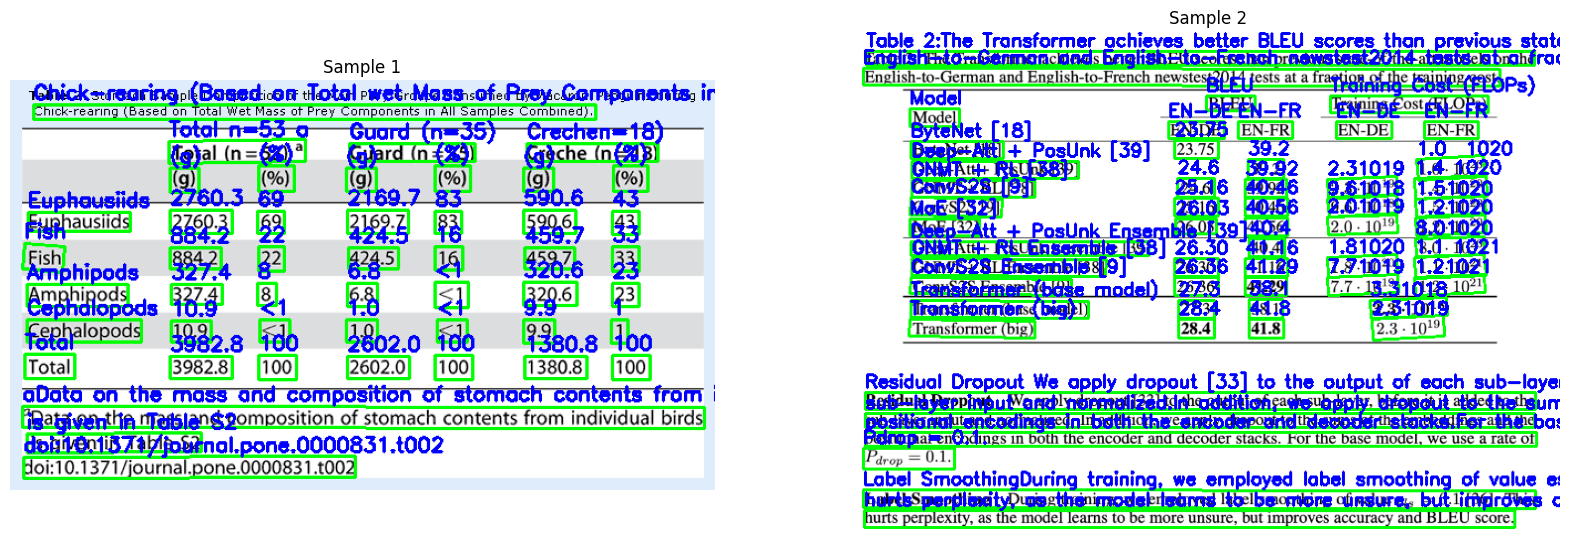

In [9]:
# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Show the first image in the first slot
ax[0].imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
ax[0].set_title("Sample 1")
ax[0].axis("off")

# Show the second image in the second slot
ax[1].imshow(cv2.cvtColor(img_plot2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Sample 2")
ax[1].axis("off")

plt.show()

## Agent usage

In [ ]:
import os
import getpass
from paddleocr import PaddleOCR
import openai

# Load OpenAI API key from environment
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

openai.api_key = os.environ["OPENAI_API_KEY"]

# Initialize OCR engine
ocr = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False)

print("✅ Essential Brain is ready!")

[2026/01/22 16:40:36] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\koush/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\koush/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_len

### tool function

In [20]:
from langchain.tools import tool

@tool
def paddle_ocr_read_document(image_path: str) -> str:
    """
    Extracts text from an image file using PaddleOCR. 
    Returns a formatted table with Index, Text, and Confidence scores.
    """
    result = ocr.ocr(image_path, cls=True)
    
    # Header for our table
    table_output = f"{'INDEX':<10} | {'TEXT':<25} | {'CONFIDENCE'}\n"
    table_output += "-" * 50 + "\n"
    
    if result[0]:
        for i, line in enumerate(result[0]):
            text = line[1][0]
            score = line[1][1]
            # Add each row to our string
            table_output += f"{i:<10} | {text:<25} | {score:.2f}\n"
            
    return table_output

In [21]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import create_tool_calling_agent, AgentExecutor

# 1. Select the Tools
tools = [paddle_ocr_read_document]

# 2. Setup the LLM (Using gpt-4o-mini as it's cheap and fast)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 3. Create the Prompt (This tells the agent who it is)
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that uses Paddle OCR to extract info from images."),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

# 4. Initialize the Agent and Executor
agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(
    agent=agent, 
    tools=tools, 
    verbose=True, 
    return_intermediate_steps=True
)

print("✅ Agent is ready!")

✅ Agent is ready!


In [24]:
# 1. We refine the task to explain the table structure to the LLM
task = """
Extract the Training Cost (FLOPs) for EN-DE for ALL methods from sample2.png.

CRITICAL INSTRUCTIONS:
1. In the OCR text, each model has multiple numbers following it.
2. The first numbers are BLEU scores (e.g., 27.3, 38.1). DO NOT EXTRACT THESE.
3. The Training Cost (FLOPs) is the value in scientific notation (e.g., '1.0 10^20' or '2.3 10^19').
4. Look for indices like 13, 17, 18, 22, 23, 31, 35, 36, 40, 41, 45, 49 in the OCR table.

Return as a list with model name and its training cost.
"""

# 2. Run the agent (Your original structure)
response = agent_executor.invoke({"input": task})

# 3. Display results side by side (Your original structure)
print("\n" + "─"*35 + " LLM RESULT " + "─"*33)
print("="*80)
print(response["output"])
print("="*80)



> Entering new AgentExecutor chain...

Invoking: `paddle_ocr_read_document` with `{'image_path': 'sample2.png'}`


[2026/01/22 16:55:27] ppocr DEBUG: dt_boxes num : 56, elapse : 0.12413811683654785
[2026/01/22 16:55:27] ppocr DEBUG: cls num  : 56, elapse : 0.11120915412902832
[2026/01/22 16:55:33] ppocr DEBUG: rec_res num  : 56, elapse : 5.869462728500366
INDEX      | TEXT                      | CONFIDENCE
--------------------------------------------------
0          | Table 2:The Transformer achieves better BLEU scores than previous state-of-the-art models on the | 0.99
1          | English-to-German and English-to-French newstest2014 tests at a fraction of the training cost. | 0.99
2          | BLEU                      | 1.00
3          | Training Cost (FLOPs)     | 0.97
4          | Model                     | 1.00
5          | EN-DE                     | 0.99
6          | EN-FR                     | 0.99
7          | EN-DE                     | 1.00
8          | EN-FR           